In [1]:
import matplotlib.pyplot as plt

def fibonacci_word(n):
    if n == 1:
        return "1"
    if n == 2:
        return "0"
    a, b = "1", "0"
    for _ in range(3, n + 1):
        a, b = b, b + a
    return b


def draw_fibonacci_fractal(n, step=1):
    word = fibonacci_word(n)

    x, y = [0], [0]
    direction = 1   # START UP → 90° anticlockwise rotation

    # 0:right, 1:up, 2:left, 3:down
    for idx, digit in enumerate(word, start=1):

        # draw forward
        if direction == 0:
            x.append(x[-1] + step); y.append(y[-1])
        elif direction == 1:
            x.append(x[-1]); y.append(y[-1] + step)
        elif direction == 2:
            x.append(x[-1] - step); y.append(y[-1])
        else:
            x.append(x[-1]); y.append(y[-1] - step)

        # turning rule
        if digit == '0':
            if idx % 2 == 0:        # n even
                direction = (direction + 1) % 4   # left
            else:                   # n odd
                direction = (direction - 1) % 4   # right

    plt.figure(figsize=(6,6))
    plt.plot(x, y, '-k', linewidth=2)
    plt.scatter(x, y, s=15)
    plt.axis('equal')
    plt.axis('off')
    plt.title(f"Fibonacci Word Fractal F{n} (90° Anticlockwise)")
    plt.show()

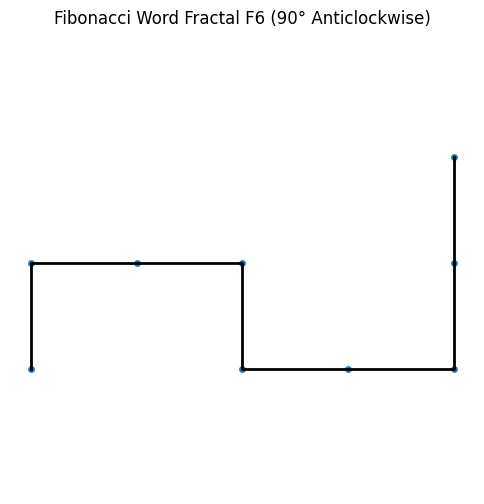

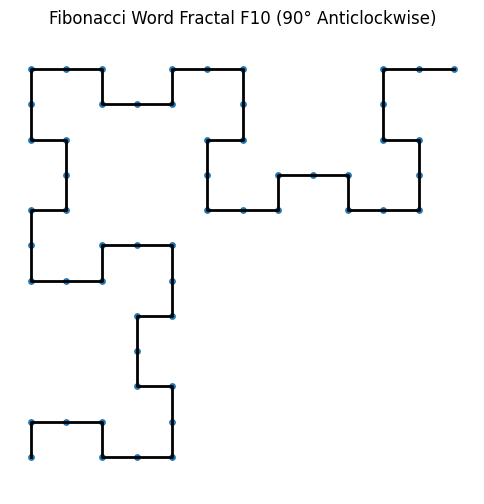

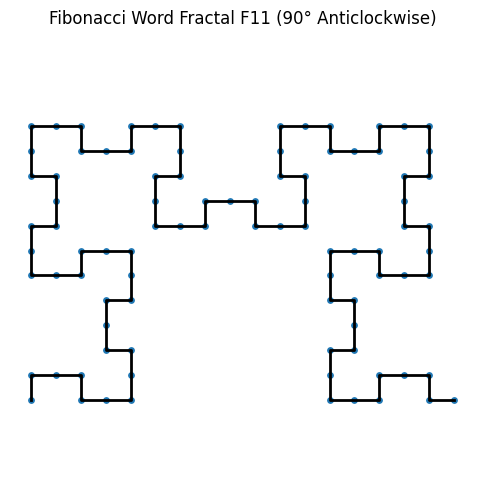

In [4]:
draw_fibonacci_fractal(6)
draw_fibonacci_fractal(10)
draw_fibonacci_fractal(11)

In [1]:
import matplotlib.pyplot as plt

# ---------------- Fibonacci word ----------------
def fibonacci_word(n):
    if n == 1:
        return "1"
    if n == 2:
        return "0"

    a, b = "1", "0"
    for _ in range(3, n + 1):
        a, b = b, b + a
    return b


# ---------------- Fibonacci word fractal ----------------
def draw_fibonacci_fractal_with_word_labels(n, step=1):
    if n < 3:
        raise ValueError("Use n ≥ 3")

    word = fibonacci_word(n)
    num_segments = len(word)

    print(f"F{n}: number of segments = {num_segments}")

    # start point
    x, y = [0], [0]

    # start UP → 90° anticlockwise rotation
    direction = 1

    # direction vectors
    directions = {
        0: (1, 0),     # right
        1: (0, 1),     # up
        2: (-1, 0),    # left
        3: (0, -1)     # down
    }

    edges = []

    # construct curve
    for k, digit in enumerate(word, start=1):
        dx, dy = directions[direction]
        x_new = x[-1] + step * dx
        y_new = y[-1] + step * dy

        edges.append((x[-1], y[-1], x_new, y_new, digit))

        x.append(x_new)
        y.append(y_new)

        # turning rule
        if digit == '0':
            if k % 2 == 0:              # even index
                direction = (direction + 1) % 4   # left
            else:                       # odd index
                direction = (direction - 1) % 4   # right

    # ---- scale-invariant label offset ----
    offset = 0.15 * step

    # plot
    plt.figure(figsize=(8, 8))
    plt.plot(x, y, '-k', linewidth=2)
    plt.scatter(x, y, s=18, color='black')

    # label edges with Fibonacci word symbols
    for x1, y1, x2, y2, digit in edges:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2

        if x1 == x2:        # vertical edge
            lx, ly = mx + offset, my
        else:               # horizontal edge
            lx, ly = mx, my + offset

        plt.text(lx, ly, digit,
                 fontsize=10,
                 color='red',
                 ha='center',
                 va='center')

    plt.axis('equal')
    plt.axis('off')
    plt.title(
        f"Fibonacci Word Fractal F{n}\n"
        f"Word = {word}\n"
        f"Number of segments = {num_segments}"
    )
    plt.show()


F7: number of segments = 13


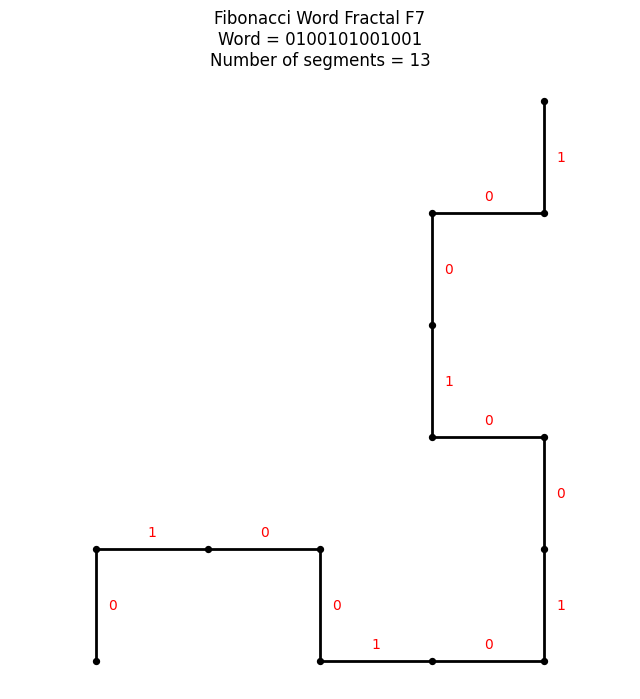

F10: number of segments = 55


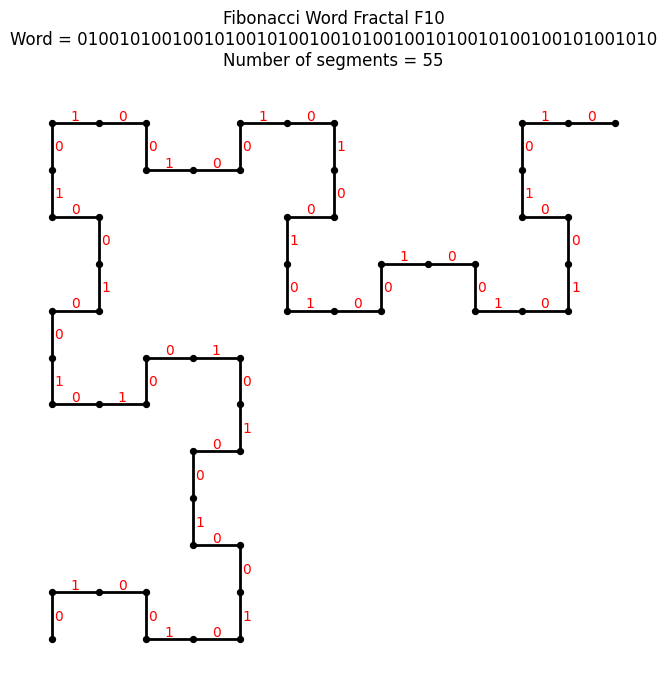

F11: number of segments = 89


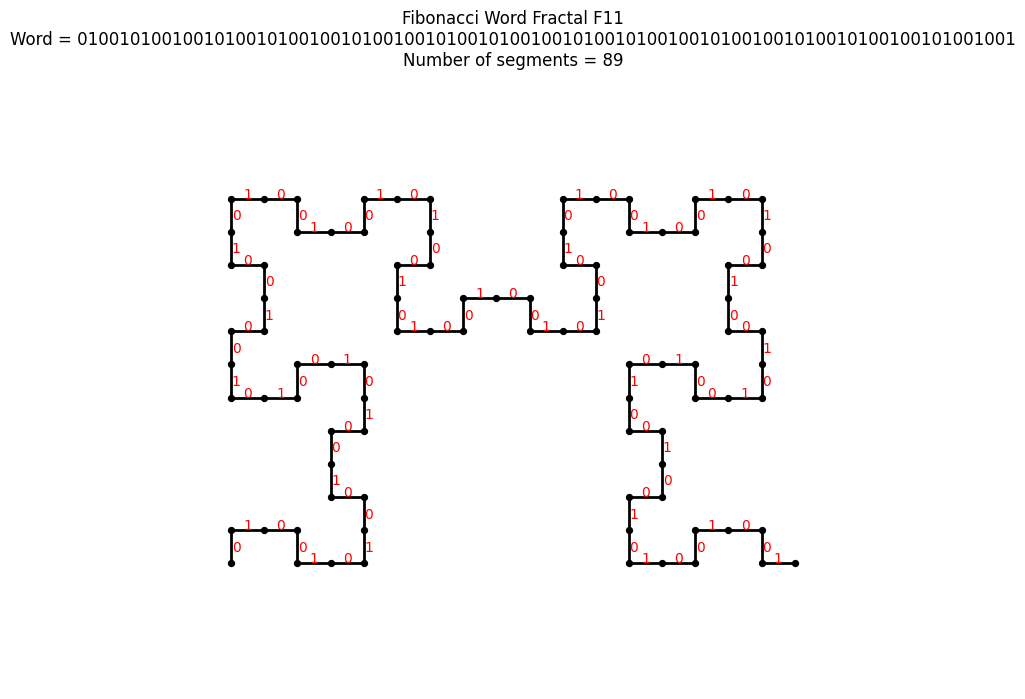

F12: number of segments = 144


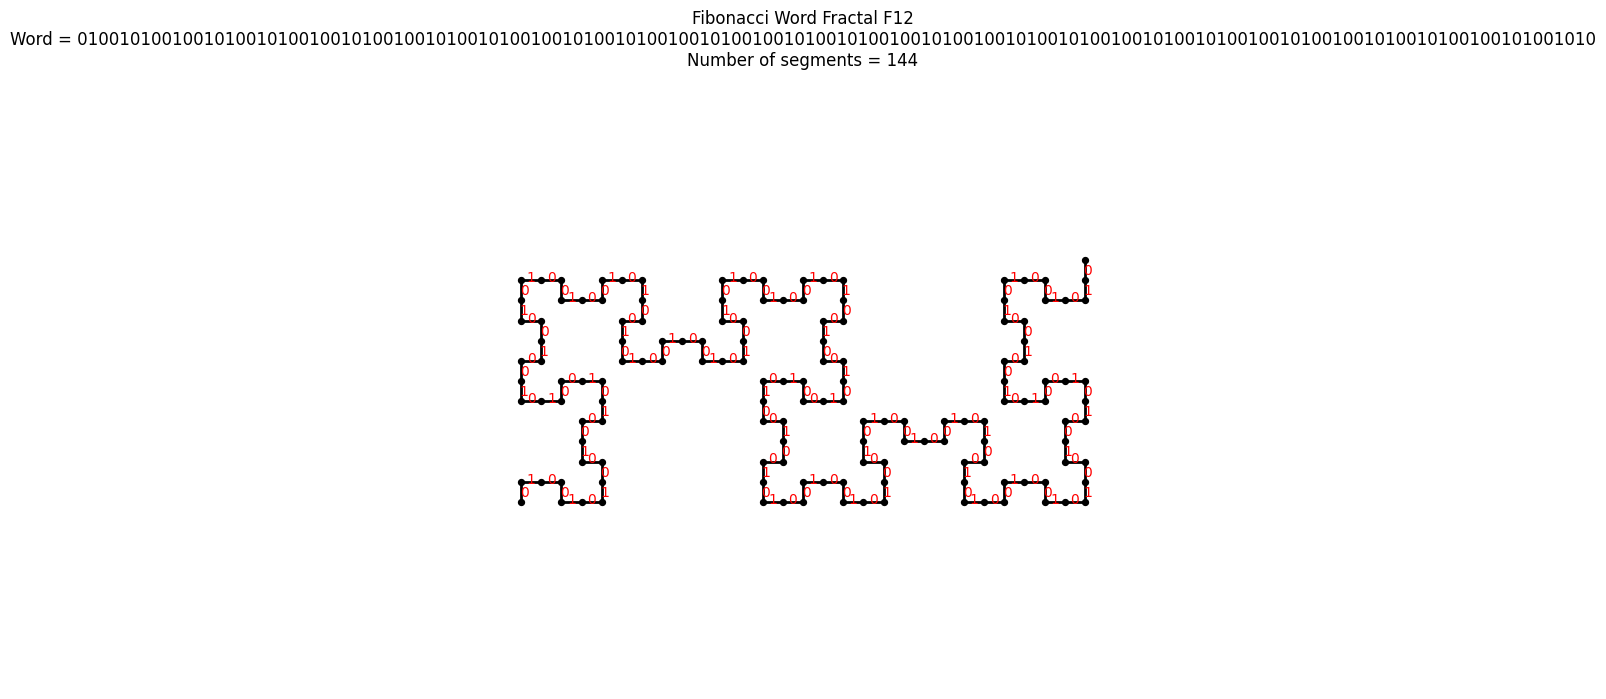

In [3]:
draw_fibonacci_fractal_with_word_labels(7)
draw_fibonacci_fractal_with_word_labels(10)
draw_fibonacci_fractal_with_word_labels(11)
draw_fibonacci_fractal_with_word_labels(12)



In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Fibonacci word ----------
def fibonacci_word(n):
    if n == 1:
        return "1"
    if n == 2:
        return "0"
    a, b = "1", "0"
    for _ in range(3, n + 1):
        a, b = b, b + a
    return b


# ---------- Odd graceful vertex labeling ----------
def odd_graceful_vertex_label(i, Fn):
    return i if i % 2 == 0 else 2 * Fn - i


# ---------- Final clean odd graceful fractal ----------
def draw_fibonacci_fractal_odd_graceful_final(n, step=1):
    if n < 3:
        raise ValueError("Use n ≥ 3")

    word = fibonacci_word(n)
    Fn = len(word)
    V = Fn + 1

    vertex_labels = [odd_graceful_vertex_label(i, Fn) for i in range(V)]

    x, y = [0.0], [0.0]
    direction = 1  # start UP (90° anticlockwise)

    directions = {
        0: np.array([1, 0]),
        1: np.array([0, 1]),
        2: np.array([-1, 0]),
        3: np.array([0, -1])
    }

    edges = []

    for k, digit in enumerate(word, start=1):
        dvec = directions[direction]
        x.append(x[-1] + step * dvec[0])
        y.append(y[-1] + step * dvec[1])
        edges.append((k - 1, k, dvec.copy()))

        if digit == '0':
            direction = (direction + 1) % 4 if k % 2 == 0 else (direction - 1) % 4

    x, y = np.array(x), np.array(y)

    plt.figure(figsize=(9, 9))
    plt.plot(x, y, '-k', linewidth=2, zorder=1)
    plt.scatter(x, y, s=22, color='black', zorder=2)

    # ----- vertex labels (angle-bisector normal) -----
    v_off = 0.28 * step
    for i in range(V):
        vx, vy = x[i], y[i]
        vecs = []

        if i > 0:
            vecs.append(np.array([x[i] - x[i-1], y[i] - y[i-1]]))
        if i < V - 1:
            vecs.append(np.array([x[i+1] - x[i], y[i+1] - y[i]]))

        if len(vecs) == 2:
            v1 = vecs[0] / np.linalg.norm(vecs[0])
            v2 = vecs[1] / np.linalg.norm(vecs[1])
            bis = v1 + v2
            normal = np.array([-bis[1], bis[0]]) if np.linalg.norm(bis) > 1e-6 \
                     else np.array([-v1[1], v1[0]])
        else:
            v = vecs[0] / np.linalg.norm(vecs[0])
            normal = np.array([-v[1], v[0]])

        normal = normal / np.linalg.norm(normal)
        lx, ly = vx + v_off * normal[0], vy + v_off * normal[1]

        plt.text(lx, ly, f"{vertex_labels[i]}",
                 fontsize=9, color='blue',
                 ha='center', va='center', zorder=4)

    # ----- edge labels (normal + alternating side) -----
    e_off = 0.30 * step
    for idx, (i, j, dvec) in enumerate(edges):
        mx, my = (x[i] + x[j]) / 2, (y[i] + y[j]) / 2
        d = dvec / np.linalg.norm(dvec)
        normal = np.array([-d[1], d[0]])
        sign = 1 if idx % 2 == 0 else -1

        lx, ly = mx + sign * e_off * normal[0], my + sign * e_off * normal[1]
        edge_label = abs(vertex_labels[i] - vertex_labels[j])

        plt.text(lx, ly, f"{edge_label}",
                 fontsize=9, color='red',
                 ha='center', va='center', zorder=4)

    plt.axis('equal')
    plt.axis('off')
    plt.title(
        f"Odd Graceful Labeling of Fibonacci Word Fractal F{n}\n"
        f"Edges = {Fn}, Vertices = {V}"
    )
    plt.show()


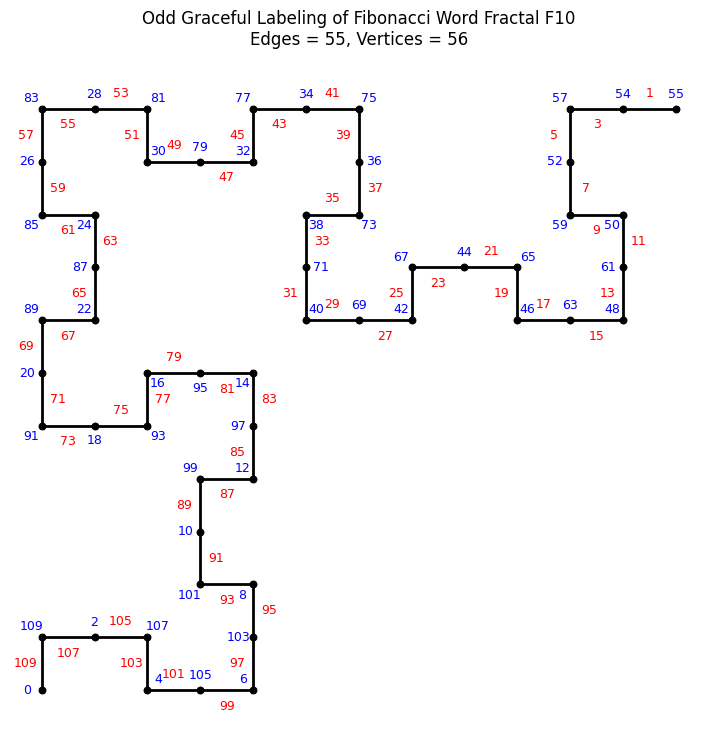

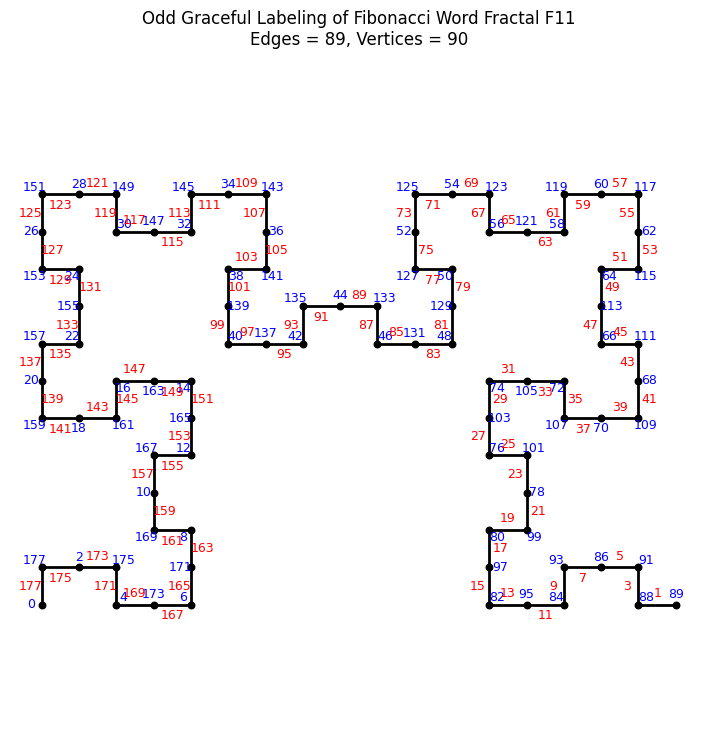

In [5]:
draw_fibonacci_fractal_odd_graceful_final(10)
draw_fibonacci_fractal_odd_graceful_final(11)


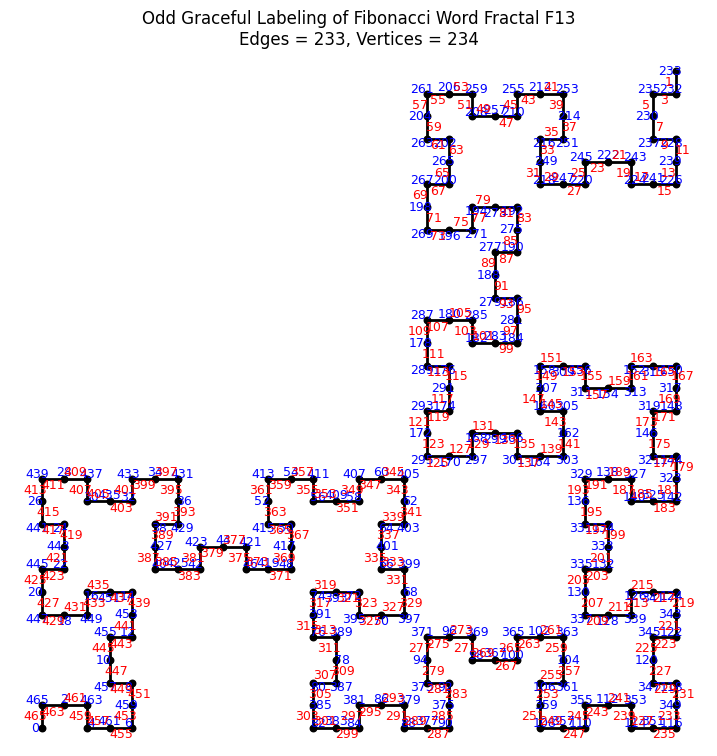

In [9]:
draw_fibonacci_fractal_odd_graceful_final(13)